In [10]:
!nvidia-smi
import torch
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")


Wed Aug  5 16:54:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!pip install apache-airflow

In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Initialize the database architecture locally inside Colab
!airflow db init

Usage: airflow db [-h] COMMAND ...

Database operations

Positional Arguments:
  COMMAND
    check             Check if the database can be reached
    check-migrations  Check if migrations have finished
    clean             Purge old records in metastore tables
    downgrade         Downgrade the schema of the metadata database.
    drop-archived     Drop archived tables created through the db clean command
    export-archived   Export archived data from the archive tables
    migrate           Migrates the metadata database to the latest version
    reset             Burn down and rebuild the metadata database
    shell             Runs a shell to access the database

Options:
  -h, --help          show this help message and exit

airflow db command error: argument COMMAND: invalid choice: 'init' (choose from check, check-migrations, clean, downgrade, drop-archived, export-archived, migrate, reset, shell), see help above.


In [3]:
!airflow db migrate

2026-08-05T16:40:00.459024Z [info     ] Performing upgrade to the metadata database [airflow.cli.commands.db_command] loc=db_command.py:134 url=sqlite:////root/airflow/airflow.db
2026-08-05T16:40:00.564836Z [info     ] setup plugin alembic.autogenerate.schemas [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565099Z [info     ] setup plugin alembic.autogenerate.tables [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565277Z [info     ] setup plugin alembic.autogenerate.types [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565426Z [info     ] setup plugin alembic.autogenerate.constraints [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565610Z [info     ] setup plugin alembic.autogenerate.defaults [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565748Z [info     ] setup plugin alembic.autogenerate.comments [alembic.runtime.plugins] loc=plugins.py:37
2026-08-05T16:40:00.565907Z [info     ] setup plugin alembic.a

In [4]:
import os
os.environ['AIRFLOW_HOME'] = '/content/airflow'

In [7]:
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime

def preprocess():
  with open("/content/MLOPS_preprocess.py", "r") as file:
            code = file.read()
            exec(code, globals())

def train():
  with open("/content/MLOPS_train.py", "r") as file:
            code = file.read()
            exec(code, globals())

def inference():
  with open("/content/MLOPS_inference.py", "r") as file:
            code = file.read()
            exec(code, globals())

default_args = {
    'owner': 'colab_user',
    'start_date': datetime(2026, 1, 1), # Uses the current year timeline
    'retries': 1
}

# 3. Instantiate the DAG
with DAG(
    dag_id='Facial_Landmarks_Detection',
    default_args=default_args,
    schedule=None,  # Triggered manually or ad-hoc
    catchup=True
) as dag:
    # 4. Define the PythonOperator Task
    task_preprocess = PythonOperator(
        task_id='preprocess',
        python_callable=preprocess
    )

    task_train = PythonOperator(
        task_id='train',
        python_callable=train
    )

    task_inference = PythonOperator(
        task_id='infer',
        python_callable=inference
    )

    task_preprocess >> task_train >> task_inference

2026-08-05T16:47:51.227056Z [warning  ] The `airflow.operators.python.PythonOperator` attribute is deprecated. Please use `'airflow.providers.standard.operators.python.PythonOperator'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_9948/3620874162.py lineno=2


In [9]:
!airflow tasks test Facial_Landmarks_Detection execute task_preprocess >> task_train >> task_inference

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "/usr/local/lib/python3.12/dist-packages/sqlalchemy/engine/default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.OperationalError: no such table: dag_bundle

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/bin/airflow", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/airflow/__main__.py", line 55, in main
    args.func(args)
  File "/usr/local/lib/python3.12/dist-packages/airflow/cli/cli_config.py", line 49, in command
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/airflow/utils/cli.py", line 113, in wrapper
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File 

In [7]:
# %load /content/MLOPS_preprocess.py
import os
import random
from math import cos, sin, radians, floor
import xml.etree.ElementTree as ET
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from torchvision import transforms
import imutils

from pyspark.sql import SparkSession
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StructType, StructField, StringType, ArrayType, FloatType, MapType

if not os.path.exists('/content/ibug_300W_large_face_landmark_dataset'):
    print("Downloading dataset...")
    os.system("wget -q http://dlib.net/files/data/ibug_300W_large_face_landmark_dataset.tar.gz")
    os.system("tar -xzf ibug_300W_large_face_landmark_dataset.tar.gz")
    os.system("rm ibug_300W_large_face_landmark_dataset.tar.gz")

# 1. Initialize Spark Session
spark = SparkSession.builder \
    .appName("FaceLandmarksPreprocessing") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# 2. Distributed XML Parsing Strategy
# Instead of parsing the massive XML sequentially on the master node,
# we extract the raw image-nodes and let Spark workers process them.
def parse_xml_to_metadata(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    metadata_list = []
    root_dir = 'ibug_300W_large_face_landmark_dataset'

    # root[2] corresponds to the images list in the DLIB XML structure
    for filename in root[2]:
        file_path = os.path.join(root_dir, filename.attrib['file'])

        # Extract crop box attributes
        crop_attribs = dict(filename[0].attrib)

        # Extract 68 landmarks coordinates
        landmarks = []
        for num in range(68):
            x = float(filename[0][num].attrib['x'])
            y = float(filename[0][num].attrib['y'])
            landmarks.append([x, y])

        metadata_list.append((file_path, crop_attribs, landmarks))
    return metadata_list

# Extract metadata sequentially first to parallelize across workers
xml_file_path = 'ibug_300W_large_face_landmark_dataset/labels_ibug_300W_train.xml'
raw_metadata = parse_xml_to_metadata(xml_file_path)

# Define PySpark Schema
schema = StructType([
    StructField("image_path", StringType(), False),
    StructField("crops", MapType(StringType(), StringType()), False),
    StructField("landmarks", ArrayType(ArrayType(FloatType())), False)
])

# Create Distributed DataFrame
df = spark.createDataFrame(raw_metadata, schema=schema)

# 3. Distributed Train/Validation Split
# PySpark handles random splitting reliably across partitions
train_df, valid_df = df.randomSplit([0.9, 0.1], seed=42)

print(f"The length of Train set is {train_df.count()}")
print(f"The length of Valid set is {valid_df.count()}")

# 4. PySpark-Compatible Transform Class
class SparkTransforms:
    def __init__(self):
        self.color_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)

    def crop_and_prep(self, image_path, landmarks, crops):
        # Read image using OpenCV (or PIL)
        image = cv2.imread(image_path, 0)
        if image is None:
            return None, None

        image = Image.fromarray(image)
        landmarks = np.array(landmarks, dtype=np.float32)

        # 1. Crop face
        left, top = int(crops['left']), int(crops['top'])
        width, height = int(crops['width']), int(crops['height'])
        image = TF.crop(image, top, left, height, width)

        img_shape = np.array(image).shape
        landmarks = landmarks - np.array([[left, top]])
        landmarks = landmarks / np.array([img_shape[1], img_shape[0]])

        # 2. Resize
        image = TF.resize(image, (224, 224))

        # 3. Color Jitter
        image = self.color_jitter(image)

        # 4. Rotate
        angle = random.uniform(-10, 10)
        transformation_matrix = np.array([
            [cos(radians(angle)), -sin(radians(angle))],
            [sin(radians(angle)), cos(radians(angle))]
        ])
        image = imutils.rotate(np.array(image), angle)
        landmarks = landmarks - 0.5
        new_landmarks = np.matmul(landmarks, transformation_matrix)
        new_landmarks = new_landmarks + 0.5

        # 5. Normalize and Convert to Tensor
        image_tensor = TF.to_tensor(Image.fromarray(image))
        image_tensor = TF.normalize(image_tensor, [0.5], [0.5])

        # Standardizing landmarks output (-0.5 offset matches original script)
        final_landmarks = new_landmarks - 0.5

        return image_tensor.numpy().tolist(), final_landmarks.tolist()

# 5. PyTorch Distributed Dataset Wrapper for Spark Dataframes
class SparkPyTorchDataset(torch.utils.data.Dataset):
    """
    Consumes collected Spark partitions or local partition views
    to serve batches to PyTorch Dataloaders seamlessly.
    """
    def __init__(self, spark_dataframe):
        # Collect data locally on workers/drivers during local training setups
        # For multi-node distributed training, use Horovod or TorchDistributor directly over DataFrames
        self.data = spark_dataframe.collect()
        self.transformer = SparkTransforms()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]

        # Perform transformations on the fly during training iteration
        img_tensor_list, landmarks_list = self.transformer.crop_and_prep(
            row['image_path'],
            row['landmarks'],
            row['crops']
        )

        # Fallback handling for missing/corrupted files
        if img_tensor_list is None:
            return self.__getitem__((idx + 1) % self.__len__())

        return torch.tensor(img_tensor_list), torch.tensor(landmarks_list)

# 6. Instantiate DataLoaders for PyTorch Model Consumption
train_dataset = SparkPyTorchDataset(train_df)
valid_dataset = SparkPyTorchDataset(valid_df)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=8, shuffle=True, num_workers=0)

# 7. Testing the shape of input data
images, landmarks = next(iter(train_loader))
print("Final PyTorch Batch Dimensions via PySpark Pipeline:")
print(f"Images Shape: {images.shape}")
print(f"Landmarks Shape: {landmarks.shape}")


The length of Train set is 6025
The length of Valid set is 641
Final PyTorch Batch Dimensions via PySpark Pipeline:
Images Shape: torch.Size([64, 1, 224, 224])
Landmarks Shape: torch.Size([64, 68, 2])


Training Loss in epoch 1


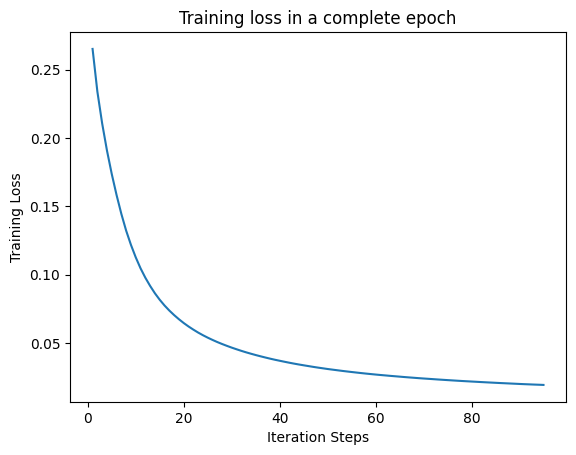

Validation Loss in epoch 1


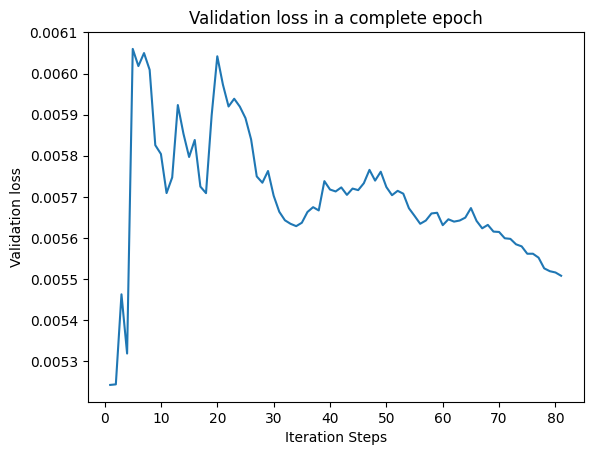


--------------------------------------------------
Epoch: 1  Train Loss: 0.0194  Valid Loss: 0.0055
--------------------------------------------------

Minimum Validation Loss of 0.0055 at epoch 1/5
Model Saved

Training Loss in epoch 2


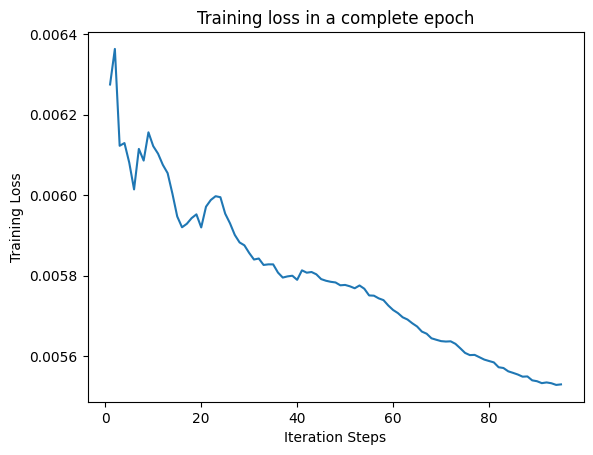

Validation Loss in epoch 2


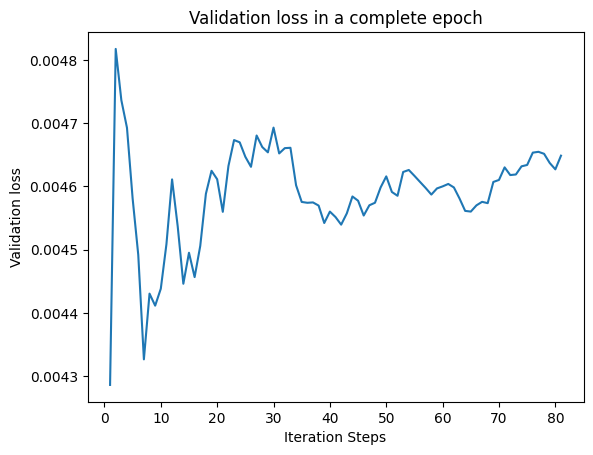


--------------------------------------------------
Epoch: 2  Train Loss: 0.0055  Valid Loss: 0.0046
--------------------------------------------------

Minimum Validation Loss of 0.0046 at epoch 2/5
Model Saved

Training Loss in epoch 3


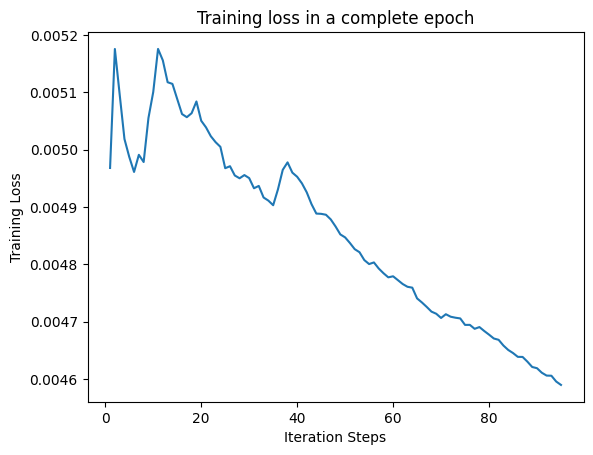

Validation Loss in epoch 3


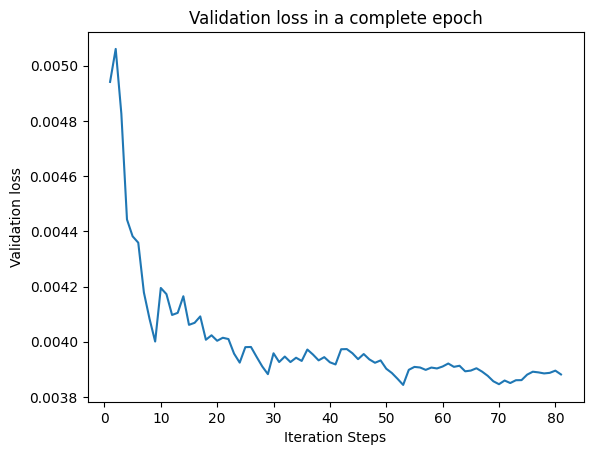


--------------------------------------------------
Epoch: 3  Train Loss: 0.0046  Valid Loss: 0.0039
--------------------------------------------------

Minimum Validation Loss of 0.0039 at epoch 3/5
Model Saved

Training Loss in epoch 4


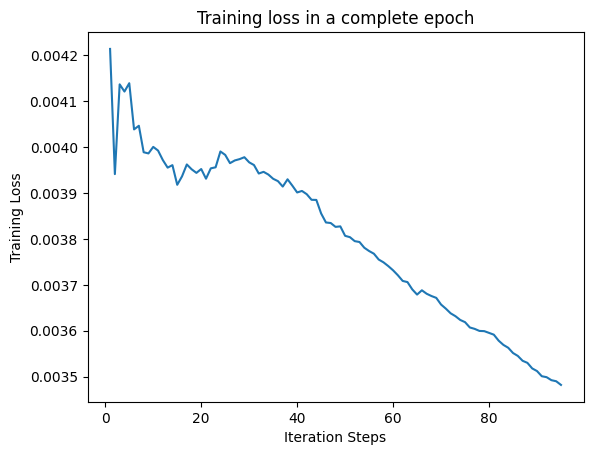

Validation Loss in epoch 4


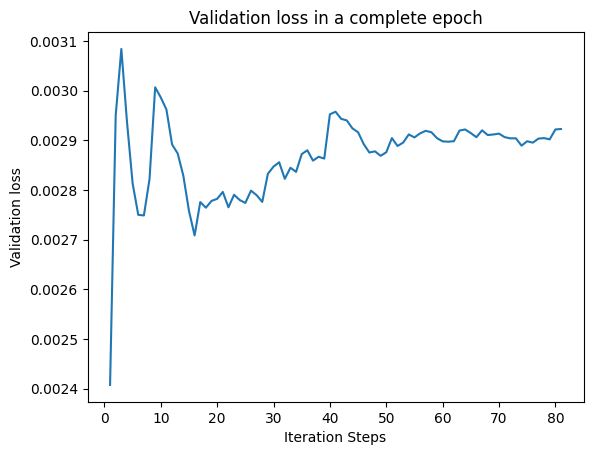


--------------------------------------------------
Epoch: 4  Train Loss: 0.0035  Valid Loss: 0.0029
--------------------------------------------------

Minimum Validation Loss of 0.0029 at epoch 4/5
Model Saved

Training Loss in epoch 5


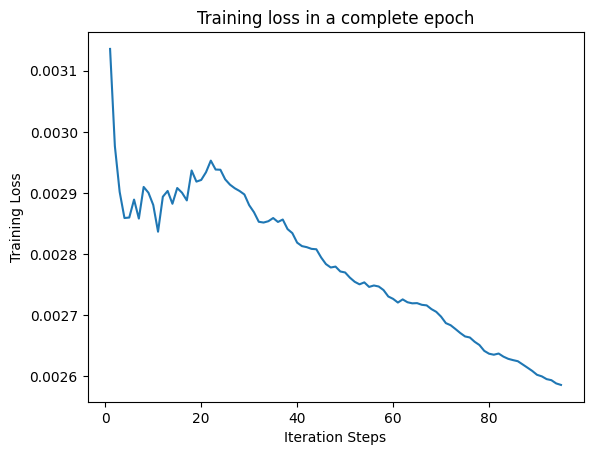

Validation Loss in epoch 5


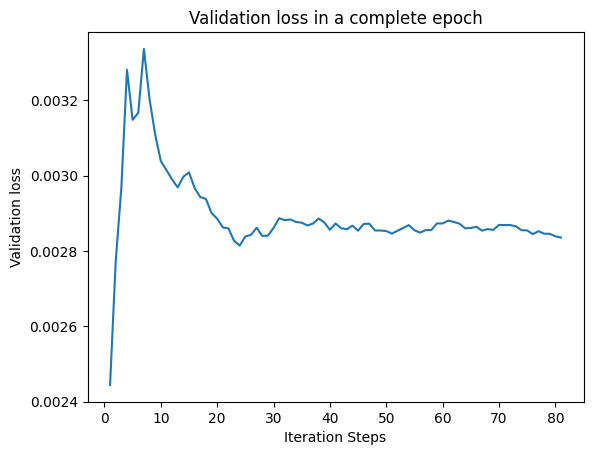

2026/08/05 16:33:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--------------------------------------------------
Epoch: 5  Train Loss: 0.0026  Valid Loss: 0.0028
--------------------------------------------------

Minimum Validation Loss of 0.0028 at epoch 5/5
Model Saved

Training Complete
Total Elapsed Time : 773.2600619792938 s


2026/08/05 16:33:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/08/05 16:33:17 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/05 16:33:25 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the loca

Model successfully saved and registered at: models:/m-759c19b5625040409d4d283c7d67110f


Successfully registered model 'Resnet_Facial_Landmarks_Model'.
Created version '1' of model 'Resnet_Facial_Landmarks_Model'.


In [9]:
# %load /content/MLOPS_train.py
import time
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imutils
import matplotlib.image as mpimg
from collections import OrderedDict
from skimage import io, transform
from math import *
import xml.etree.ElementTree as ET

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.pytorch
mlflow.set_experiment("Facial LandMarks Detection")

with mlflow.start_run(run_name="Best_Model") as run:
  class Network(nn.Module):
    def __init__(self,num_classes=136):
        super().__init__()
        self.model_name='resnet18'
        self.model=models.resnet18()
        self.model.conv1=nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        x=self.model(x)
        return x

  torch.autograd.set_detect_anomaly(True)
  network = Network()
  network.cuda()

  criterion = nn.MSELoss()
  optimizer = optim.Adam(network.parameters(), lr=0.0001)

  loss_min = np.inf
  num_epochs = 5

  start_time = time.time()
  for epoch in range(1,num_epochs+1):
    loss_train = 0
    loss_valid = 0
    running_loss = 0
    l_t = []
    l_v = []
    network.train()
    for step in range(1,len(train_loader)+1):
        images, landmarks = next(iter(train_loader))
        images = images.cuda()
        landmarks = landmarks.view(landmarks.size(0),-1).cuda()
        predictions = network(images)
        # clear all the gradients before calculating them
        optimizer.zero_grad()
        # find the loss for the current step
        loss_train_step = criterion(predictions, landmarks)
        # calculate the gradients
        loss_train_step.backward()
        # update the parameters
        optimizer.step()
        loss_train += loss_train_step.item()
        running_loss = loss_train/step
        l_t.append(running_loss)
        #print_overwrite(step, len(train_loader), running_loss, 'train')
    print("Training Loss in epoch", epoch )
    plt.plot(range(1,len(train_loader)+1), l_t)
    plt.xlabel('Iteration Steps')
    plt.ylabel('Training Loss')
    plt.title('Training loss in a complete epoch')
    plt.show()
    network.eval()
    with torch.no_grad():
        for step in range(1,len(valid_loader)+1):
          images, landmarks = next(iter(valid_loader))
          images = images.cuda()
          landmarks = landmarks.view(landmarks.size(0),-1).cuda()
          predictions = network(images)
          # find the loss for the current step
          loss_valid_step = criterion(predictions, landmarks)
          loss_valid += loss_valid_step.item()
          running_loss = loss_valid/step
          l_v.append(running_loss)
          #print_overwrite(step, len(valid_loader), running_loss, 'valid')
    print("Validation Loss in epoch", epoch )
    plt.plot(range(1,len(valid_loader)+1), l_v)
    plt.xlabel('Iteration Steps')
    plt.ylabel('Validation loss')
    plt.title('Validation loss in a complete epoch')
    plt.show()
    loss_train /= len(train_loader)
    loss_valid /= len(valid_loader)
    print('\n--------------------------------------------------')
    print('Epoch: {}  Train Loss: {:.4f}  Valid Loss: {:.4f}'.format(epoch, loss_train, loss_valid))
    print('--------------------------------------------------')
    if loss_valid < loss_min:
        loss_min = loss_valid
        torch.save(network.state_dict(), '/content/face_landmarks.pth')
        print("\nMinimum Validation Loss of {:.4f} at epoch {}/{}".format(loss_min, epoch, num_epochs))
        print('Model Saved\n')
  print('Training Complete')
  print("Total Elapsed Time : {} s".format(time.time()-start_time))

  # Save, log, and register the optimal model instance inside the MLflow Model Registry
  model_info = mlflow.pytorch.log_model(
    pytorch_model=network,
    artifact_path="best_network",
    registered_model_name="Resnet_Facial_Landmarks_Model",
    serialization_format="pickle"  # <--- Add this line
    )
  mlflow.log_metrics({
            "MSE_Validation_loss": loss_min
        }, step=epoch)
  #mlflow.log_artifact(images, artifact_path="images")
  #mlflow.log_artifact(landmarks, artifact_path="landmarks")
  #mlflow.log_artifact(predictions, artifact_path="Validation_predictions")

print(f"Model successfully saved and registered at: {model_info.model_uri}")


Loading model from registry: models:/Resnet_Facial_Landmarks_Model/1...
Total number of test images: 641
Elapsed Time : 0.30256104469299316


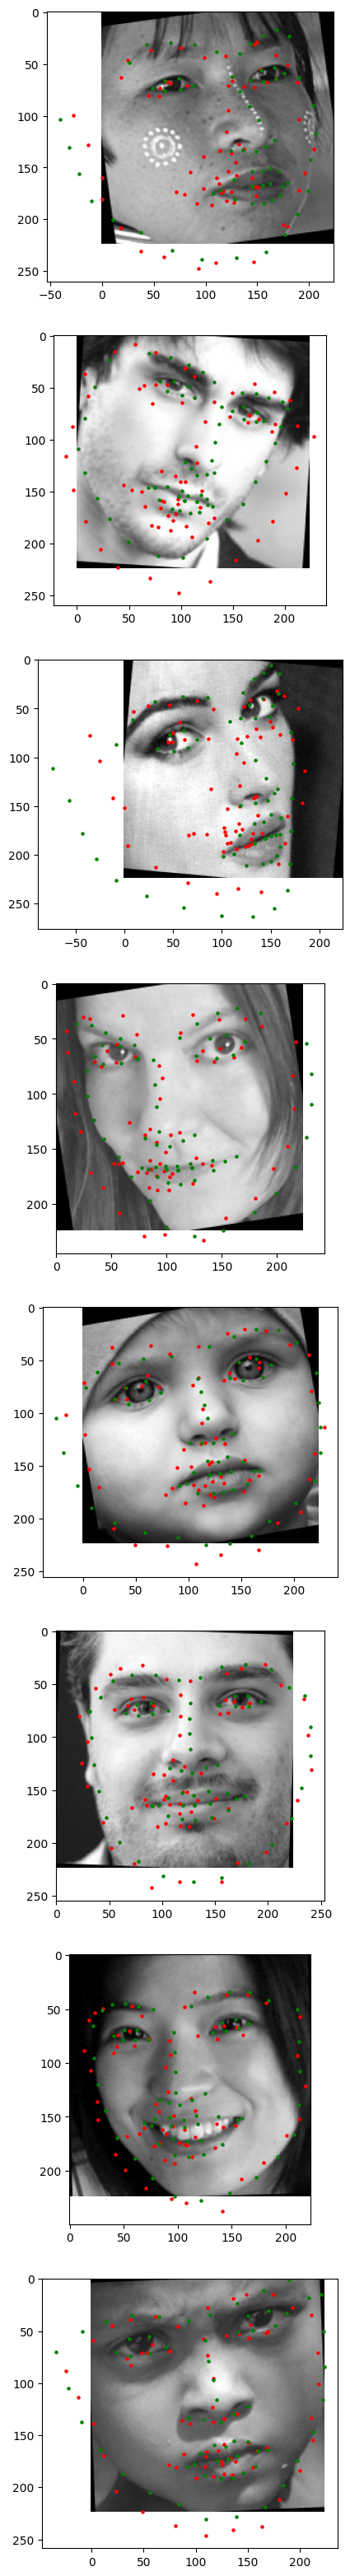

In [11]:
# %load /content/MLOPS_inference.py
import mlflow.pytorch
import pandas as pd

# Define constants
# TODO: Replace '123456' with your actual roll number
#ROLL_NUMBER = "da25m600"
MODEL_NAME = "Resnet_Facial_Landmarks_Model"
MODEL_VERSION = "1"  # Or use a stage like 'Production' (e.g., f"models:/{MODEL_NAME}/Production")
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"

#INPUT_FILE = "/content/test_processed_da25m600.parquet"
#OUTPUT_FILE = f"predictions_{ROLL_NUMBER}.csv"


def run_inference():
    print(f"Loading model from registry: {MODEL_URI}...")
    # Load the registered model as a PyFunc model
    model = mlflow.pytorch.load_model(model_uri=MODEL_URI)
    start_time = time.time()
    with torch.no_grad():
      best_network = model
      best_network.cuda()
      best_network.load_state_dict(torch.load('/content/face_landmarks.pth'))
      best_network.eval()
      images, landmarks = next(iter(valid_loader))
      images = images.cuda()
      landmarks = (landmarks + 0.5) * 224
      predictions = (best_network(images).cpu() + 0.5) * 224
      predictions = predictions.view(-1,68,2)
      plt.figure(figsize=(10,40))
      for img_num in range(8):
        plt.subplot(8,1,img_num+1)
        plt.imshow(images[img_num].cpu().numpy().transpose(1,2,0).squeeze(), cmap='gray')
        plt.scatter(predictions[img_num,:,0], predictions[img_num,:,1], c = 'r', s = 5)
        plt.scatter(landmarks[img_num,:,0], landmarks[img_num,:,1], c = 'g', s = 5)

    print('Total number of test images: {}'.format(len(valid_dataset)))
    end_time = time.time()
    print("Elapsed Time : {}".format(end_time - start_time))

if __name__ == "__main__":
    run_inference()